# **Title: IoT Network Traffic Analysis**
# Dataset:
https://www.kaggle.com/datasets/emilynack/aci-iot-network-traffic-dataset-2023



**Reference:** Nathaniel Bastian, David Bierbrauer, Morgan McKenzie, Emily Nack, December 29, 2023, " ACI IoT Network Traffic Dataset 2023", IEEE Dataport, doi: https://dx.doi.org/10.21227/qacj-3x32.

Report: [Link](https://docs.google.com/document/d/15o_UhTC8v17gbnlxSAIEWiN4ZomAUSgxckqmAYrV1PU/edit?usp=sharing)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
dataset = pd.read_csv('/content/drive/My Drive/Dataset2/dataset.csv')

Mounted at /content/drive


##**Data Analysis**##

In [ ]:
main_frame = pd.DataFrame(dataset)
main_frame.shape

(1231411, 85)

In [ ]:
null=main_frame.isnull().sum().sum()
print(f"Total number of Null values in Dataset: {null}")

Total number of Null values in Dataset: 1009


In [ ]:
ac=main_frame['Label'].unique()
for i in ac:
  print(i)

Benign
ICMP Flood
Slowloris
SYN Flood
UDP Flood
DNS Flood
Dictionary Attack
OS Scan
Port Scan
Ping Sweep
Vulnerability Scan
ARP Spoofing


In [ ]:
non_numeric_columns = main_frame.select_dtypes(exclude='number').columns
num_non_numeric_columns = len(non_numeric_columns)

print(f'The number of columns with non-numeric values is: {num_non_numeric_columns}')
print('Non-numeric columns:', non_numeric_columns)

The number of columns with non-numeric values is: 6
Non-numeric columns: Index(['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Label', 'Connection Type'], dtype='object')


In [ ]:
main_frame.head(100)


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Connection Type
0,192.168.1.7-54.230.163.60-33344-443-6,192.168.1.7,33344,54.230.163.60,443,6,2023-01-11 09:43:40,379933,11,11,...,0.000000,0.000000,0.0,0.0,1.698846e+15,0.000000e+00,1.698846e+15,1.698846e+15,Benign,wired
1,192.168.3.6-91.189.91.48-36754-80-6,192.168.3.6,36754,91.189.91.48,80,6,2023-01-11 09:43:51,205637,3,3,...,0.000000,0.000000,0.0,0.0,1.698846e+15,0.000000e+00,1.698846e+15,1.698846e+15,Benign,wired
2,192.168.3.6-91.189.91.48-36754-80-6,192.168.3.6,36754,91.189.91.48,80,6,2023-01-11 09:43:51,0,2,0,...,0.000000,0.000000,0.0,0.0,1.698846e+15,0.000000e+00,1.698846e+15,1.698846e+15,Benign,wired
3,192.168.1.9-192.168.1.1-8080-40426-6,192.168.1.9,8080,192.168.1.1,40426,6,2023-01-11 09:43:49,5030379,1,2,...,0.000000,0.000000,0.0,0.0,8.494231e+14,1.201266e+15,1.698846e+15,5.030379e+06,Benign,wired
4,192.168.1.20-35.232.111.17-40054-80-6,192.168.1.20,40054,35.232.111.17,80,6,2023-01-11 09:43:56,72278,3,4,...,0.000000,0.000000,0.0,0.0,1.698846e+15,0.000000e+00,1.698846e+15,1.698846e+15,Benign,wired
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,192.168.1.86-34.117.65.55-34750-443-6,192.168.1.86,34750,34.117.65.55,443,6,2023-01-11 09:43:43,202444,8,6,...,0.000000,0.000000,0.0,0.0,1.698846e+15,0.000000e+00,1.698846e+15,1.698846e+15,Benign,wired
96,192.168.1.48-172.64.41.4-53836-443-6,192.168.1.48,53836,172.64.41.4,443,6,2023-01-11 09:43:38,54027765,20,10,...,9654.555556,1489.792528,13144.0,7588.0,1.698846e+14,5.372223e+14,1.698846e+15,5.986814e+06,Benign,wired
97,192.168.1.25-201.101.181.27-0-0-0,192.168.1.25,0,201.101.181.27,0,0,2023-01-11 09:43:42,15195638,2,0,...,0.000000,0.000000,0.0,0.0,8.494231e+14,1.201266e+15,1.698846e+15,1.519564e+07,ICMP Flood,wired
98,192.168.1.182-20.190.152.20-60609-443-6,192.168.1.182,60609,20.190.152.20,443,6,2023-01-11 09:44:08,739182,15,9,...,0.000000,0.000000,0.0,0.0,1.698846e+15,0.000000e+00,1.698846e+15,1.698846e+15,Benign,wired


In [ ]:
from sklearn.model_selection import train_test_split
Y = main_frame['Label']

dataset_subset, _ = train_test_split(main_frame, test_size=(len(main_frame) - 30000), stratify=Y, random_state=42)

label_distribution = dataset_subset['Label'].value_counts()
print("Label distribution in the subset:")
print(label_distribution)

print("Shape of the subset:", dataset_subset.shape)
main_frame=dataset_subset

Label distribution in the subset:
Label
Port Scan             10751
Benign                 8022
ICMP Flood             5487
Ping Sweep             1752
DNS Flood              1144
Vulnerability Scan      963
OS Scan                 914
Slowloris               454
SYN Flood               338
Dictionary Attack       156
UDP Flood                19
Name: count, dtype: int64
Shape of the subset: (30000, 85)


In [ ]:
null=main_frame.isnull().sum().sum()

print(f"Total number of Null values in Dataset: {null}")

Total number of Null values in Dataset: 23


##**Pre-Processing**##

Some Data Preprocessing Techniques:



*  Deleting null values
*  Imputation for missing values
*  Handling Categorical Features
*  Feature Normalization/Scaling
*  Feature Engineering
*  Feature Selection

















###Null Value###

Removing Rows with null value:

In [ ]:
print("Number of rows with null values in Flow Bytes column: ", main_frame['Flow Bytes/s'].isnull().sum())

dataset = main_frame[main_frame['Flow Bytes/s'].notnull()]

print("Shape after removing null values: ", dataset.shape)

Number of rows with null values in Flow Bytes column:  23
Shape after removing null values:  (29977, 85)


In [ ]:
null=dataset.isnull().sum().sum()

print(f"Total number of Null values in Dataset: {null}")

Total number of Null values in Dataset: 0


###Categorical Values###

####Encodiong Categorical values (Connection Type) to int:####

In [ ]:
print("Unique values in 'Connection Type':", dataset['Connection Type'].unique())

if not dataset['Connection Type'].isin([0, 1]).all():
  dataset['Connection Type'] = dataset['Connection Type'].str.strip().str.lower()
  dataset['Connection Type'] = dataset['Connection Type'].map({'wired': 0, 'wireless': 1})


Unique values in 'Connection Type': ['wired' 'wireless']


<ipython-input-12-d672253d000b>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['Connection Type'] = dataset['Connection Type'].str.strip().str.lower()
<ipython-input-12-d672253d000b>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['Connection Type'] = dataset['Connection Type'].map({'wired': 0, 'wireless': 1})


In [ ]:
print(dataset['Connection Type'].unique())

[0 1]


####Removing Categorical Features:####

In [ ]:
columns_to_drop = ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp','Src Port', 'Dst Port']
dataset = dataset.drop(columns=columns_to_drop, axis=1)


###Feature Engineering###

####Scaling down 10^15 values:####

In [ ]:
import pandas as pd

threshold = 10**12

numeric_columns = dataset.select_dtypes(include=['float64', 'int64'])
large_value_columns = [col for col in numeric_columns.columns if numeric_columns[col].max() > threshold]
dataset[large_value_columns] = dataset[large_value_columns] / 10**16
print(dataset[large_value_columns].head())

         Flow Bytes/s  Flow Packets/s  Idle Mean  Idle Std  Idle Max  Idle Min
259736   1.920356e-16    9.601779e-17   0.169885       0.0  0.169885  0.169885
520141   0.000000e+00    4.049403e-14   0.169869       0.0  0.169869  0.169869
617237   0.000000e+00    3.293808e-14   0.169868       0.0  0.169868  0.169868
1038929  2.290975e-14    1.324263e-16   0.169867       0.0  0.169867  0.169867
131574   0.000000e+00    5.261275e-16   0.169885       0.0  0.169885  0.169885


####Replaceing Inf values with NaN and removing them:####





In [ ]:
import numpy as np

inf_counts = {
    'Flow Bytes/s': np.isinf(dataset['Flow Bytes/s']).sum(),
    'Flow Packets/s': np.isinf(dataset['Flow Packets/s']).sum()
}

print("Number of 'inf' values:")
for column, count in inf_counts.items():
    print(f"{column}: {count}")

dataset.replace([np.inf, -np.inf], np.nan, inplace=True)
main_frame=dataset

main_frame = dataset.dropna(subset=['Flow Bytes/s', 'Flow Packets/s'])
print("Shape after removing rows with 'inf' values:", main_frame.shape)
print("Number of rows with null values in Flow Bytes column: ", main_frame['Flow Bytes/s'].isnull().sum())

dataset = main_frame[main_frame['Flow Bytes/s'].notnull()]
print("Shape after removing null values: ", dataset.shape)

Number of 'inf' values:
Flow Bytes/s: 21
Flow Packets/s: 21
Shape after removing rows with 'inf' values: (29956, 79)
Number of rows with null values in Flow Bytes column:  0
Shape after removing null values:  (29956, 79)


###Feature Scaling###

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
numeric_columns = dataset.select_dtypes(include=['float64', 'int64']).columns

scaler = StandardScaler()
scaled_features = scaler.fit_transform(dataset[numeric_columns])

scaled_dataset = dataset.copy()
scaled_dataset[numeric_columns] = scaled_features

print(scaled_dataset.head())


         Protocol  Flow Duration  Total Fwd Packet  Total Bwd packets  \
259736  -0.083655      -0.173604         -0.016815          -0.024375   
520141  -0.083655      -0.439572         -0.032282          -0.020373   
617237  -0.083655      -0.439475         -0.032282          -0.020373   
1038929  2.162381      -0.182461         -0.009082          -0.024375   
131574  -1.308765      -0.407583         -0.024549          -0.024375   

         Total Length of Fwd Packet  Total Length of Bwd Packet  \
259736                    -0.013283                      -0.015   
520141                    -0.013303                      -0.015   
617237                    -0.013303                      -0.015   
1038929                   -0.011029                      -0.015   
131574                    -0.013303                      -0.015   

         Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
259736               -0.123503              -0.207721               -0.169791

Removing scaled Null values:

In [ ]:
null=dataset.isnull().sum().sum()
print(null)

dataset = dataset.dropna()
print("Shape after removing rows with null values:", dataset.shape)

0
Shape after removing rows with null values: (29956, 79)


###Feature Selection###

In [ ]:
dataset = dataset.loc[:, ~dataset.columns.str.contains('mean', case=False)]
print("Shape after dropping columns with 'mean':", dataset.shape)

print("Remaining columns:", dataset.columns.tolist())
null=dataset.isnull().sum().sum()
print(null)

Shape after dropping columns with 'mean': (29956, 71)
Remaining columns: ['Protocol', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWR Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 'Average Packet Size', 'Fwd Segment Size Avg',

##**Seperating Trainning Data and Test Data**##

In [ ]:
from sklearn.model_selection import train_test_split
Y=dataset['Label']
train_set, test_set = train_test_split(dataset, test_size=0.3, random_state=42,stratify=Y)


X_train = train_set.drop('Label', axis=1)
Y_train = train_set['Label']


X_test = test_set.drop('Label', axis=1)
Y_test = test_set['Label']


##**Data Visualization**##

Correlation Heatmap of the entire Dataset:


<ipython-input-22-507714eb9845>:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_data = dataset.groupby(target_feature, group_keys=False).apply(lambda x: x.sample(min(len(x), 50)))


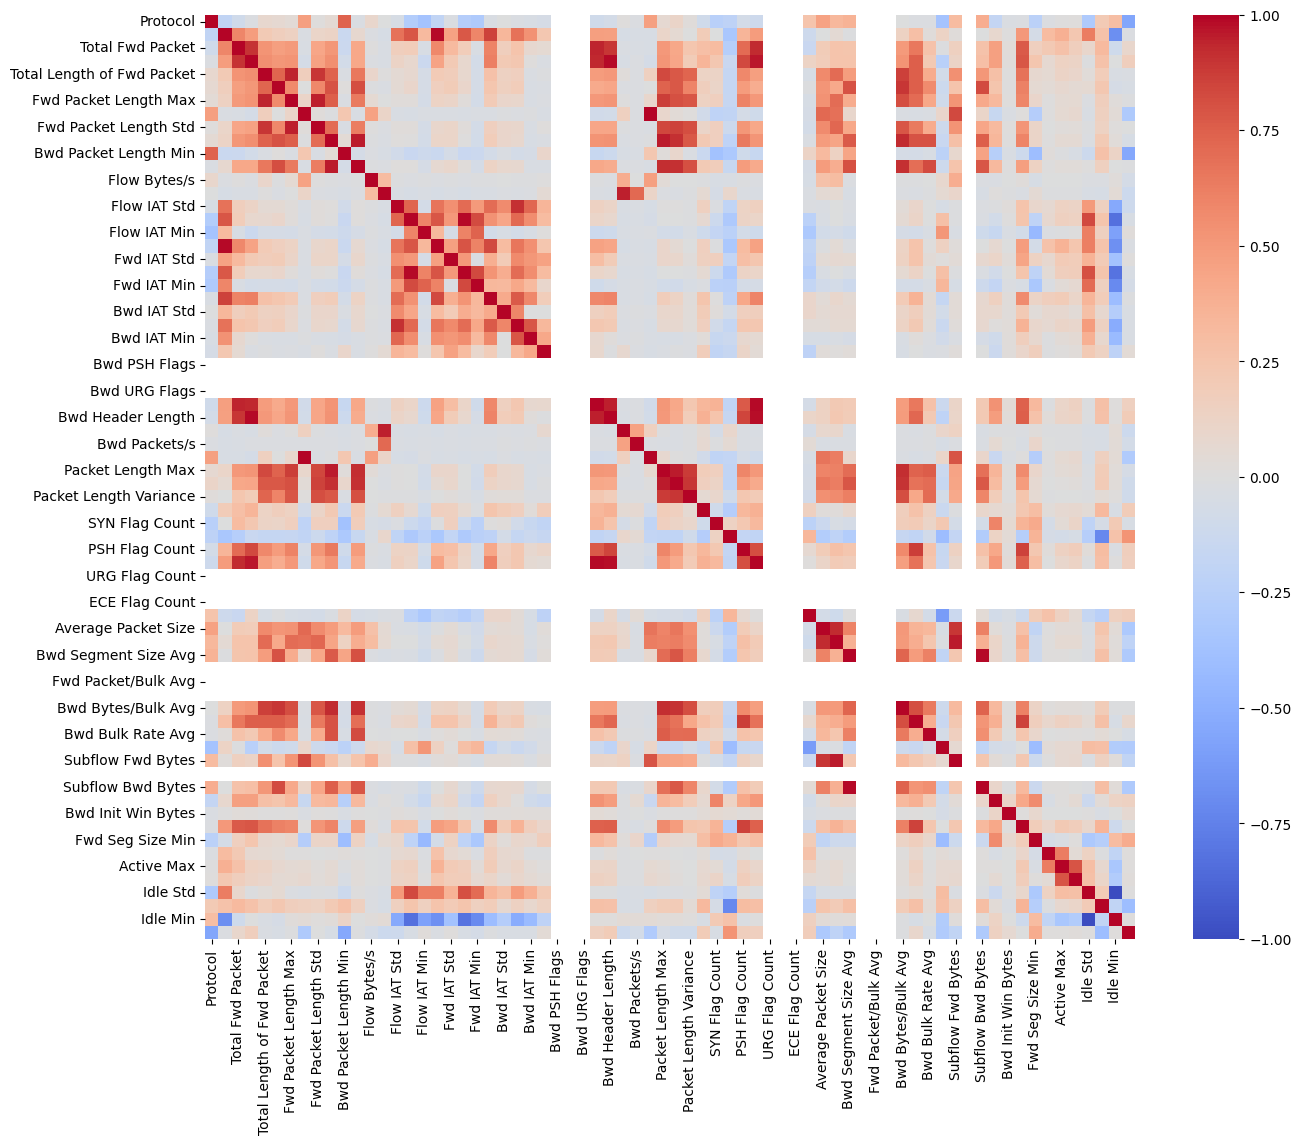

In [ ]:
target_feature = 'Label'


selected_columns = dataset.columns[dataset.columns != target_feature]


sampled_data = dataset.groupby(target_feature, group_keys=False).apply(lambda x: x.sample(min(len(x), 50)))


correlation_matrix = sampled_data[selected_columns].corr(numeric_only=True)

plt.figure(figsize=(15, 12))


sns.heatmap(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1, annot=False)


plt.show()

##**Correlation heatmap of 20 random features to understand the relations:**##

<ipython-input-43-18c2f95ac8a3>:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_data = dataset.groupby(target_feature, group_keys=False).apply(lambda x: x.sample(min(len(x), 50)))


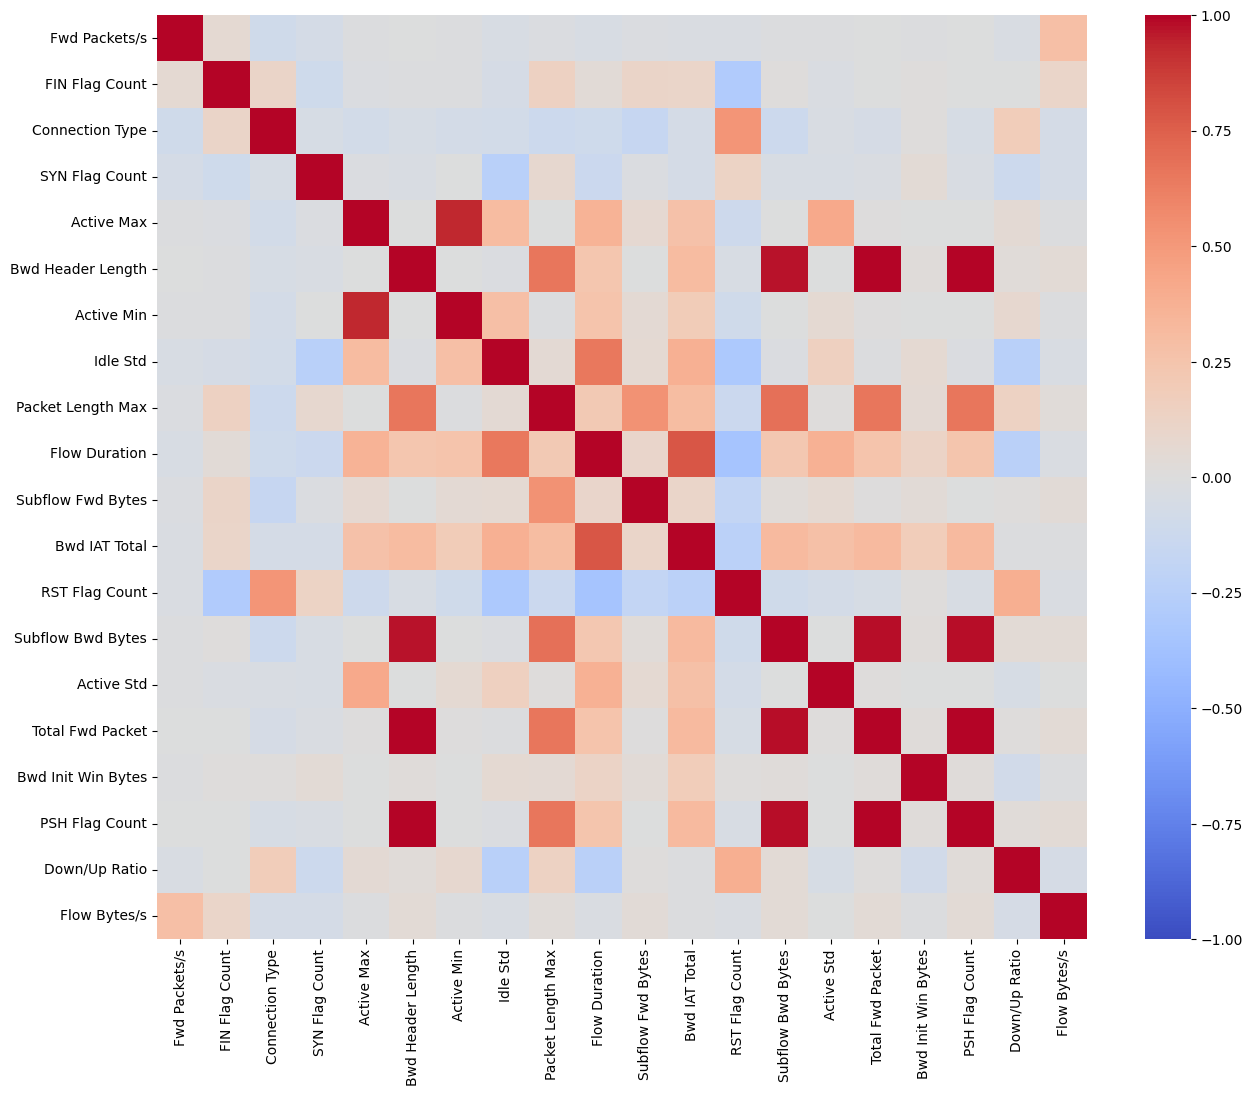

In [ ]:
import random

target_feature = 'Label'

selected_columns = dataset.columns[dataset.columns != target_feature]


random_columns = random.sample(selected_columns.tolist(), 20)

sampled_data = dataset.groupby(target_feature, group_keys=False).apply(lambda x: x.sample(min(len(x), 50)))


correlation_matrix = sampled_data[random_columns].corr(numeric_only=True)

plt.figure(figsize=(15, 12))

sns.heatmap(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1, annot=False)

plt.show()

Data Distribution of Trainning Set:

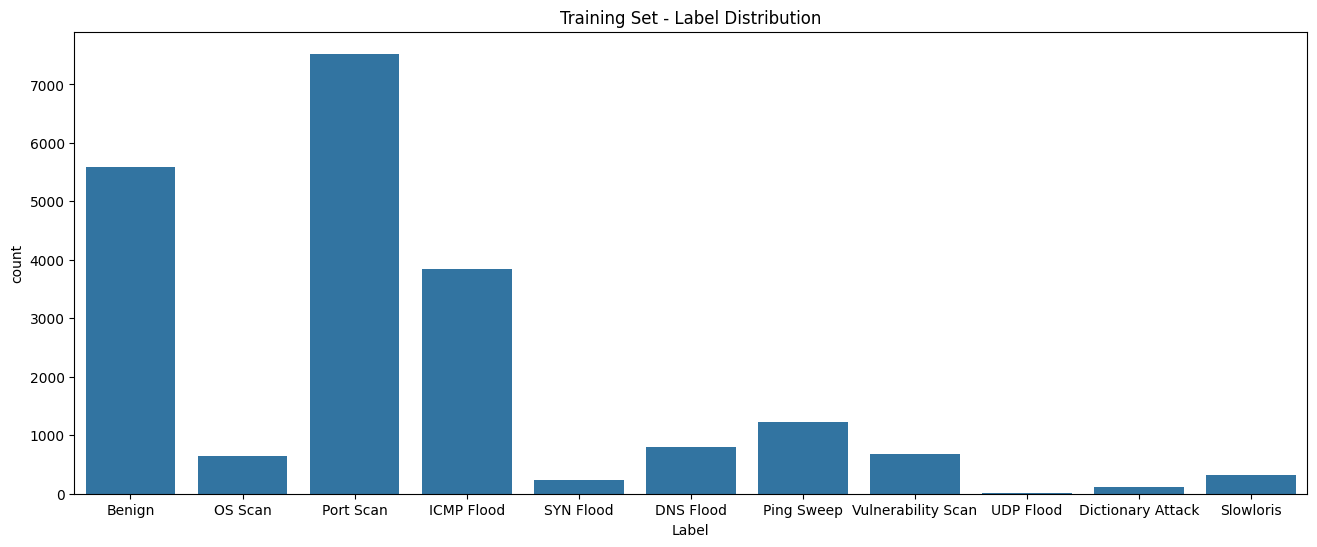

In [ ]:
plt.figure(figsize=(35, 6))
plt.subplot(1, 2, 1)
sns.countplot(x='Label', data=train_set)
plt.title('Training Set - Label Distribution')
plt.show()

Data Distribution of Test Set:

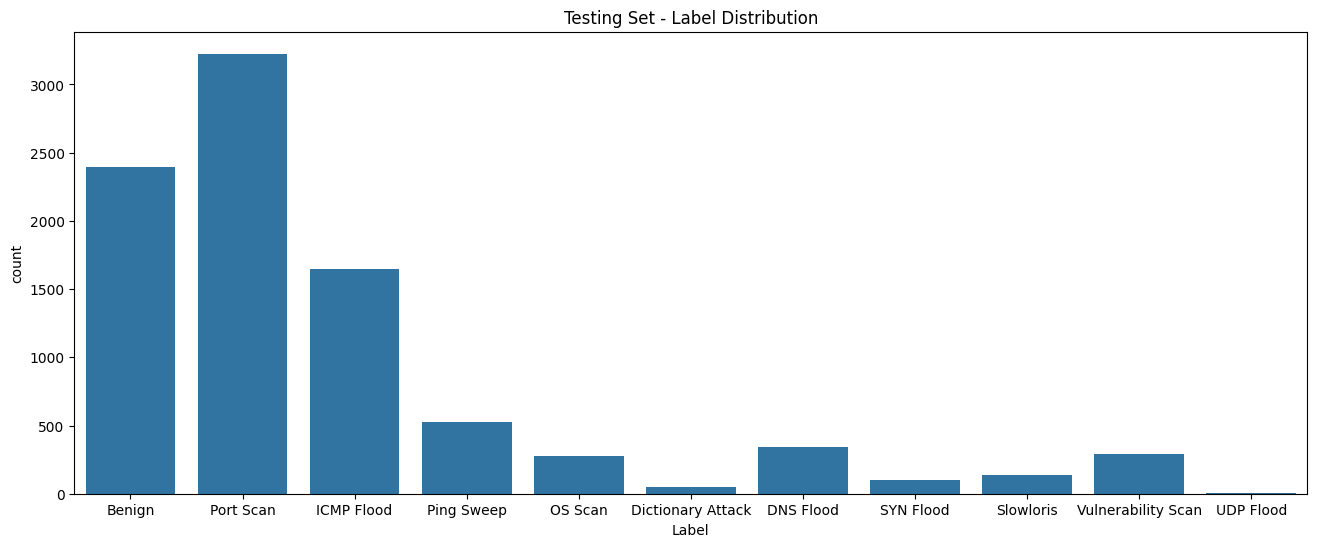

In [ ]:
plt.figure(figsize=(35, 6))
plt.subplot(1, 2, 2)
sns.countplot(x='Label', data=test_set)
plt.title('Testing Set - Label Distribution')
plt.show()

## **Trainning and Prediction Accuracy:**##

###**Model 1: Decision Tree (RandomForestClassifier)**###

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(n_estimators=20, random_state=42)
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)
accuracy = accuracy_score(Y_test, Y_pred)
print(f'Accuracy: {accuracy:.2f}')

print(classification_report(Y_test, Y_pred))

Accuracy: 0.99
                    precision    recall  f1-score   support

            Benign       0.98      0.99      0.98      2394
         DNS Flood       1.00      0.98      0.99       343
 Dictionary Attack       1.00      1.00      1.00        47
        ICMP Flood       1.00      1.00      1.00      1646
           OS Scan       1.00      0.99      0.99       274
        Ping Sweep       0.96      0.97      0.96       526
         Port Scan       1.00      1.00      1.00      3225
         SYN Flood       1.00      1.00      1.00       101
         Slowloris       0.99      0.97      0.98       136
         UDP Flood       0.00      0.00      0.00         6
Vulnerability Scan       0.99      0.97      0.98       289

          accuracy                           0.99      8987
         macro avg       0.90      0.90      0.90      8987
      weighted avg       0.99      0.99      0.99      8987



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Visualization:

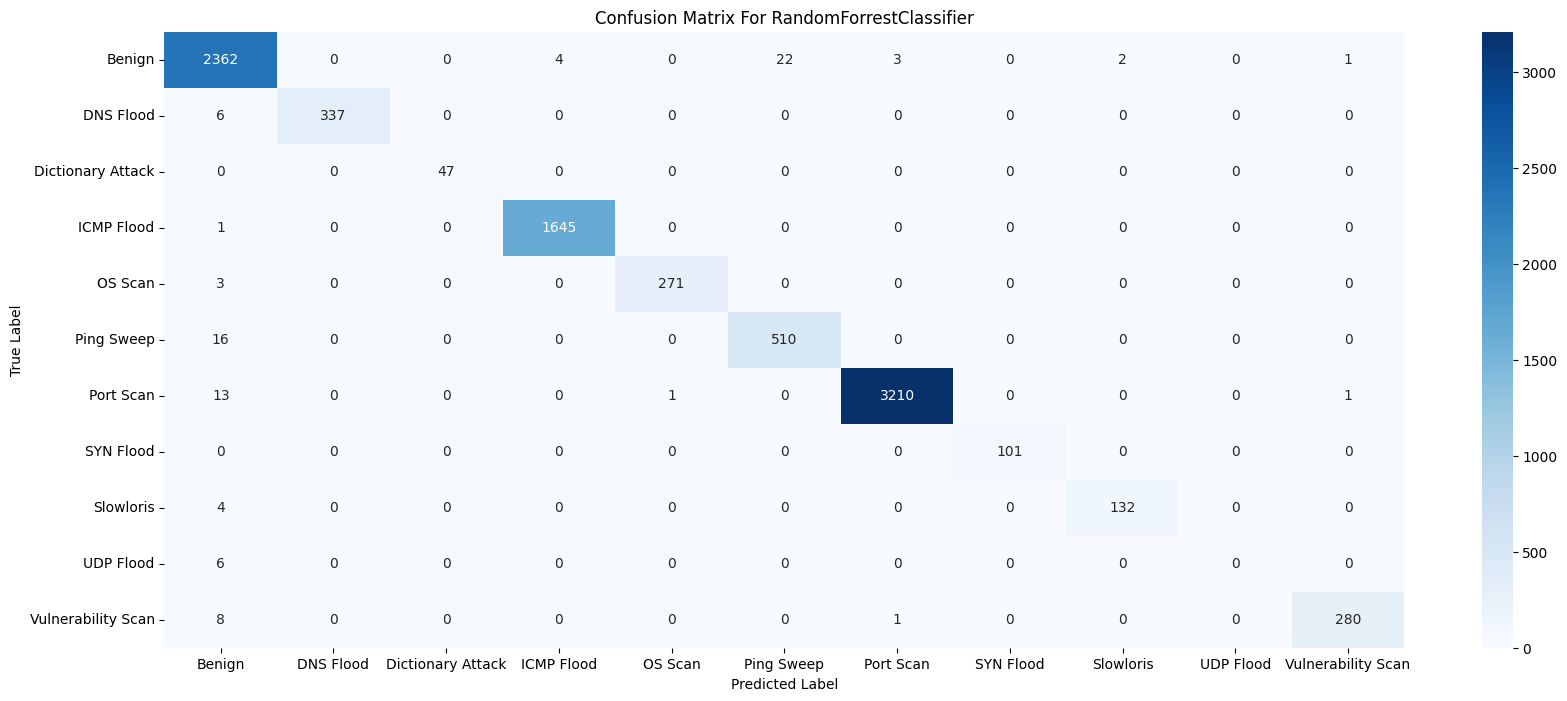

In [ ]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(20, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix For RandomForrestClassifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

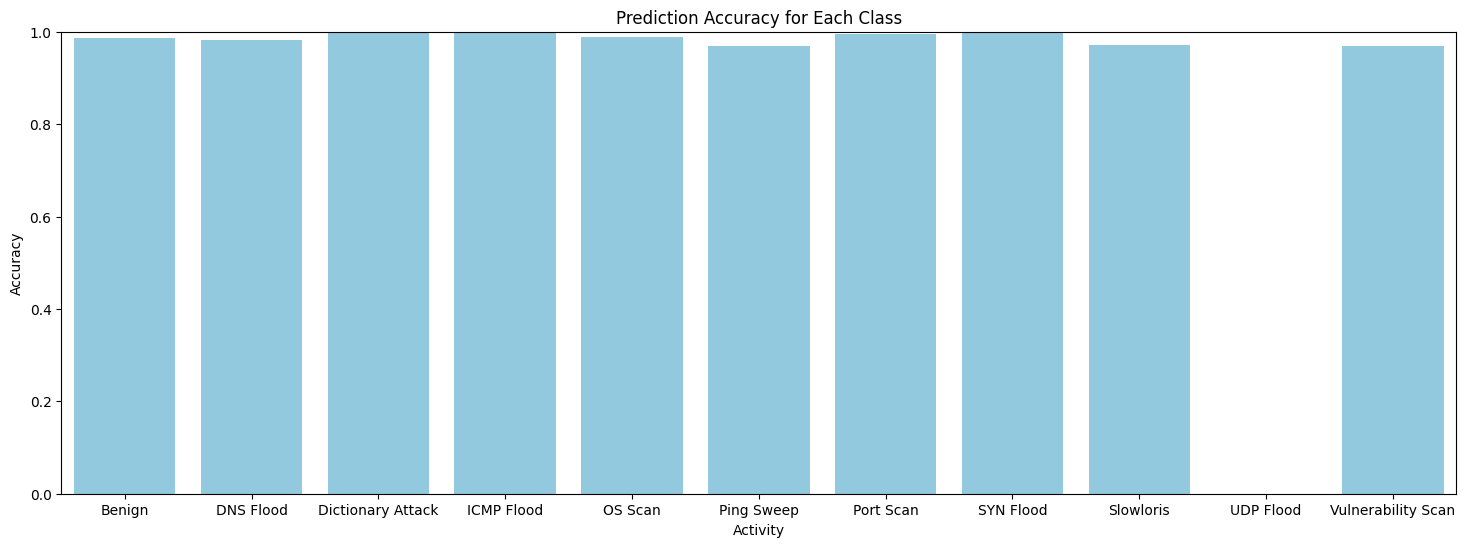

In [ ]:
class_accuracy = conf_matrix.diagonal() / conf_matrix.sum(axis=1)

plt.figure(figsize=(18, 6))
sns.barplot(x=model.classes_, y=class_accuracy, color='skyblue')
plt.title('Prediction Accuracy for Each Class')
plt.xlabel('Activity')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

###**Model 2: K-Nearest Neighbors (KNeighborsClassifier)**###

In [ ]:
from sklearn.neighbors import KNeighborsClassifier


knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, Y_train)

Y_pred_knn = knn_model.predict(X_test)
accuracy_knn = accuracy_score(Y_test, Y_pred_knn)
print(f'K-Nearest Neighbors Accuracy: {accuracy_knn:.2f}')

print('Classification Report for K-Nearest Neighbors:')
print(classification_report(Y_test, Y_pred_knn))

K-Nearest Neighbors Accuracy: 0.84
Classification Report for K-Nearest Neighbors:
                    precision    recall  f1-score   support

            Benign       0.92      0.92      0.92      2394
         DNS Flood       0.92      0.89      0.91       343
 Dictionary Attack       0.61      0.57      0.59        47
        ICMP Flood       0.98      0.98      0.98      1646
           OS Scan       0.11      0.05      0.07       274
        Ping Sweep       0.17      0.08      0.11       526
         Port Scan       0.79      0.90      0.84      3225
         SYN Flood       0.83      0.94      0.88       101
         Slowloris       0.85      0.65      0.74       136
         UDP Flood       0.00      0.00      0.00         6
Vulnerability Scan       0.95      0.93      0.94       289

          accuracy                           0.84      8987
         macro avg       0.65      0.63      0.63      8987
      weighted avg       0.81      0.84      0.82      8987



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Visualization

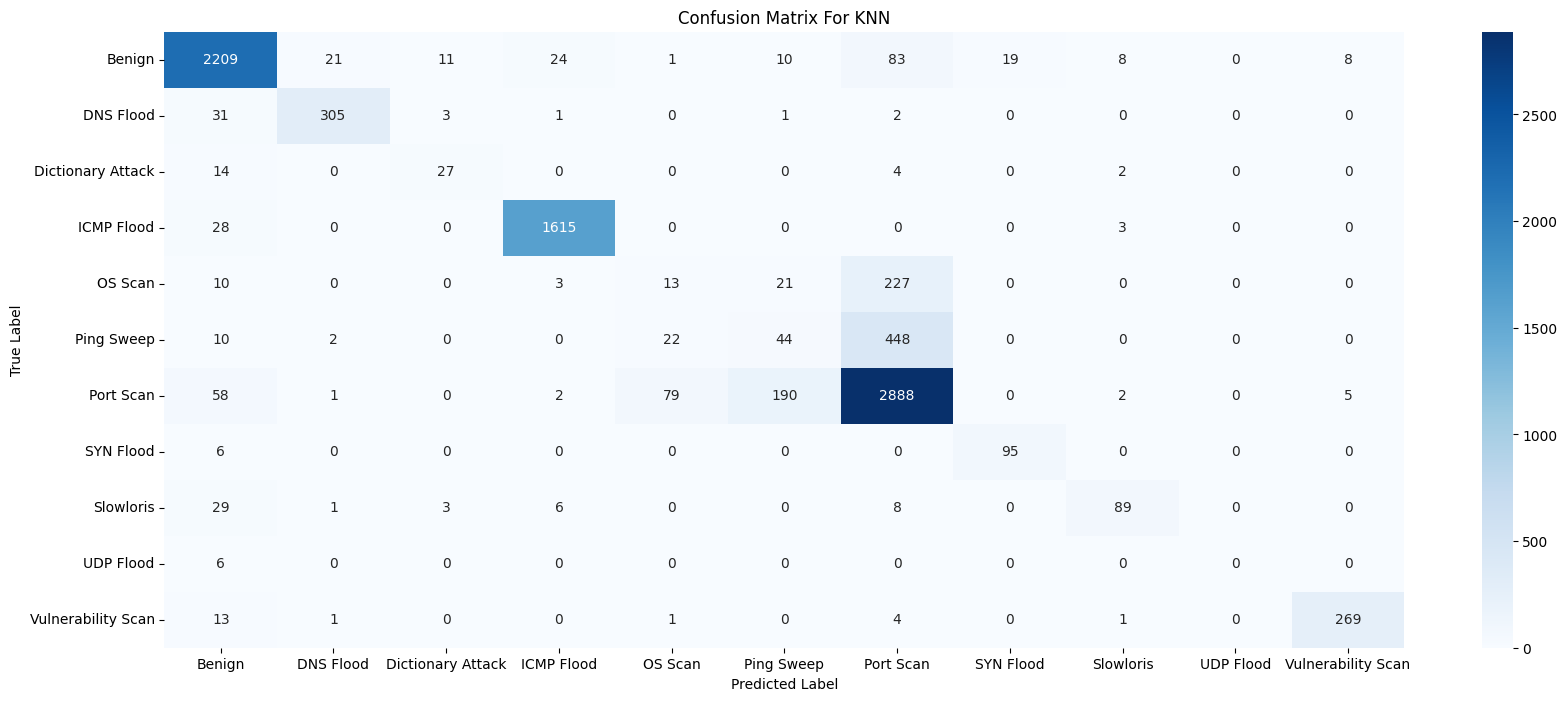

In [ ]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(Y_test, Y_pred_knn)


plt.figure(figsize=(20, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix For KNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

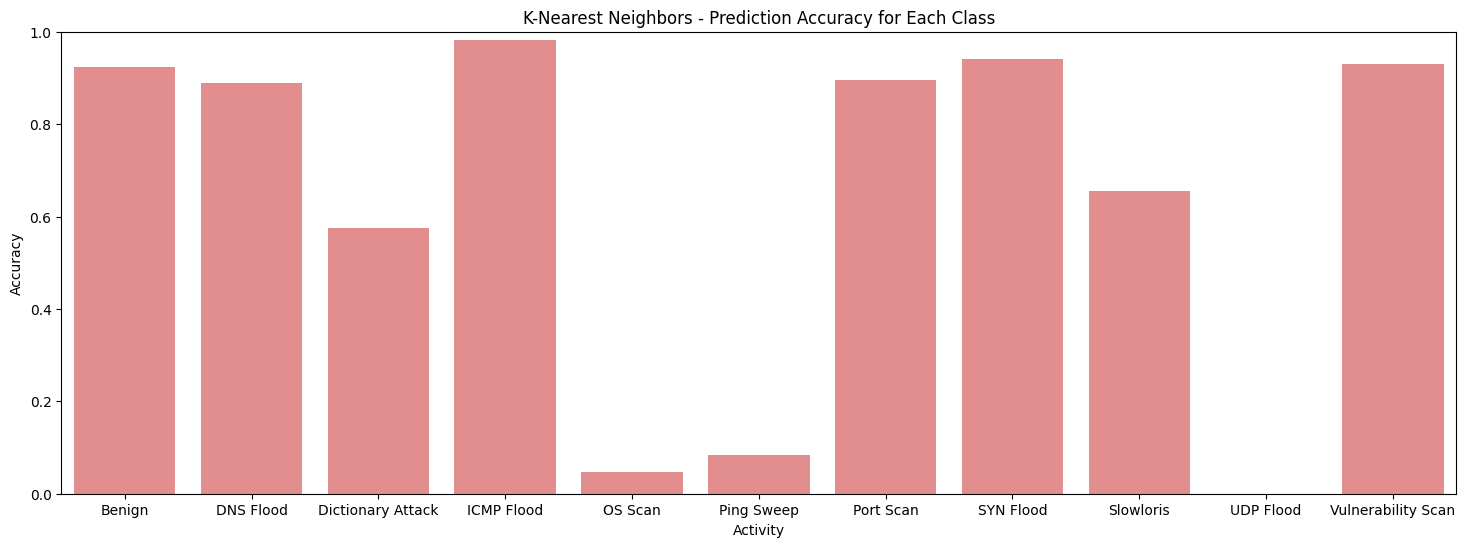

In [ ]:
class_accuracy_knn = conf_matrix.diagonal() / conf_matrix.sum(axis=1)


plt.figure(figsize=(18, 6))
sns.barplot(x=knn_model.classes_, y=class_accuracy_knn, color='lightcoral')
plt.title('K-Nearest Neighbors - Prediction Accuracy for Each Class')
plt.xlabel('Activity')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

###**Model 3: Naive Bayes Model**###

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

nb_model = GaussianNB()
nb_model.fit(X_train, Y_train)
Y_pred_nb = nb_model.predict(X_test)

accuracy_nb = accuracy_score(Y_test, Y_pred_nb)
print(f'Naive Bayes Accuracy: {accuracy_nb:.2f}')

print('Classification Report for Naive Bayes:')
print(classification_report(Y_test, Y_pred_nb))

Naive Bayes Accuracy: 0.33
Classification Report for Naive Bayes:
                    precision    recall  f1-score   support

            Benign       0.98      0.16      0.28      2394
         DNS Flood       0.40      0.05      0.09       343
 Dictionary Attack       0.19      0.47      0.27        47
        ICMP Flood       0.87      1.00      0.93      1646
           OS Scan       0.08      0.01      0.01       274
        Ping Sweep       0.10      0.98      0.19       526
         Port Scan       0.03      0.00      0.00      3225
         SYN Flood       0.73      0.99      0.84       101
         Slowloris       0.09      0.29      0.14       136
         UDP Flood       0.01      0.50      0.02         6
Vulnerability Scan       0.59      0.95      0.73       289

          accuracy                           0.33      8987
         macro avg       0.37      0.49      0.32      8987
      weighted avg       0.48      0.33      0.30      8987



Visualization:

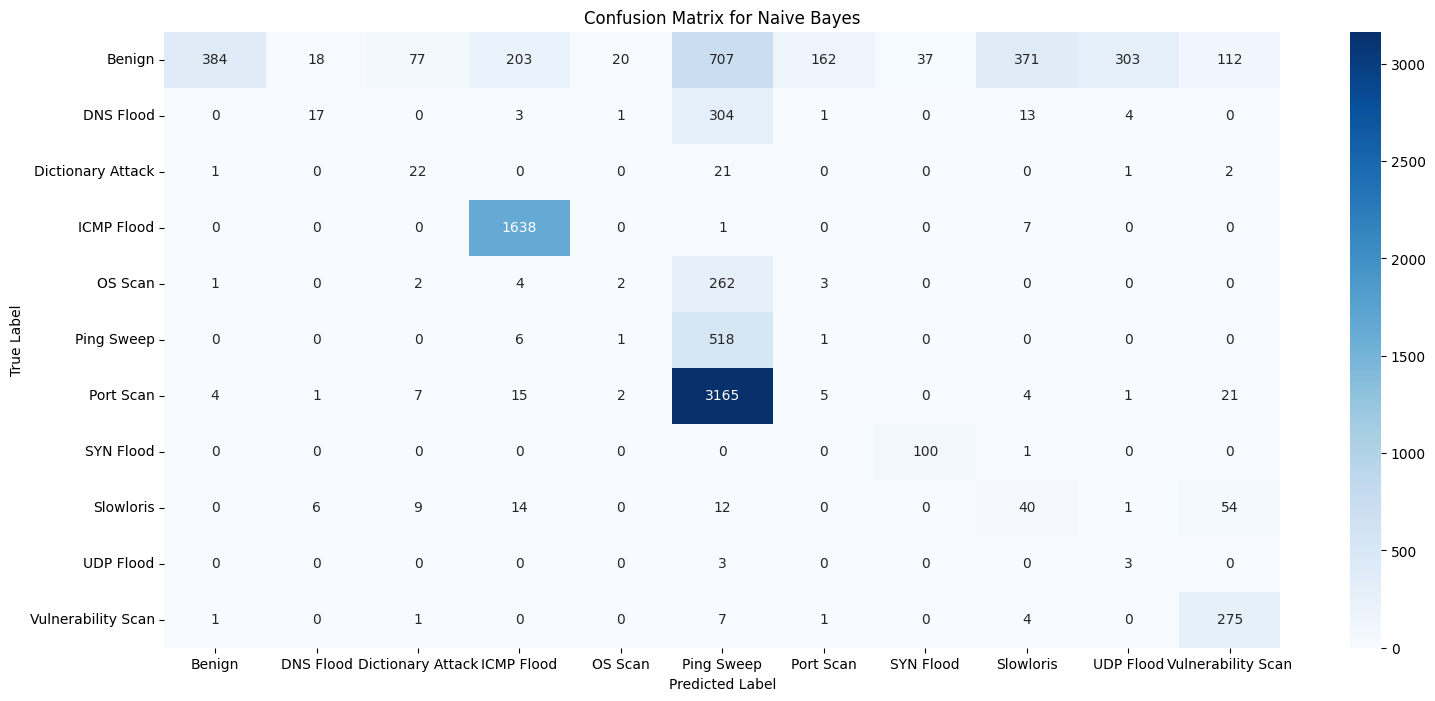

In [ ]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(Y_test, Y_pred_nb)

plt.figure(figsize=(18, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix for Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

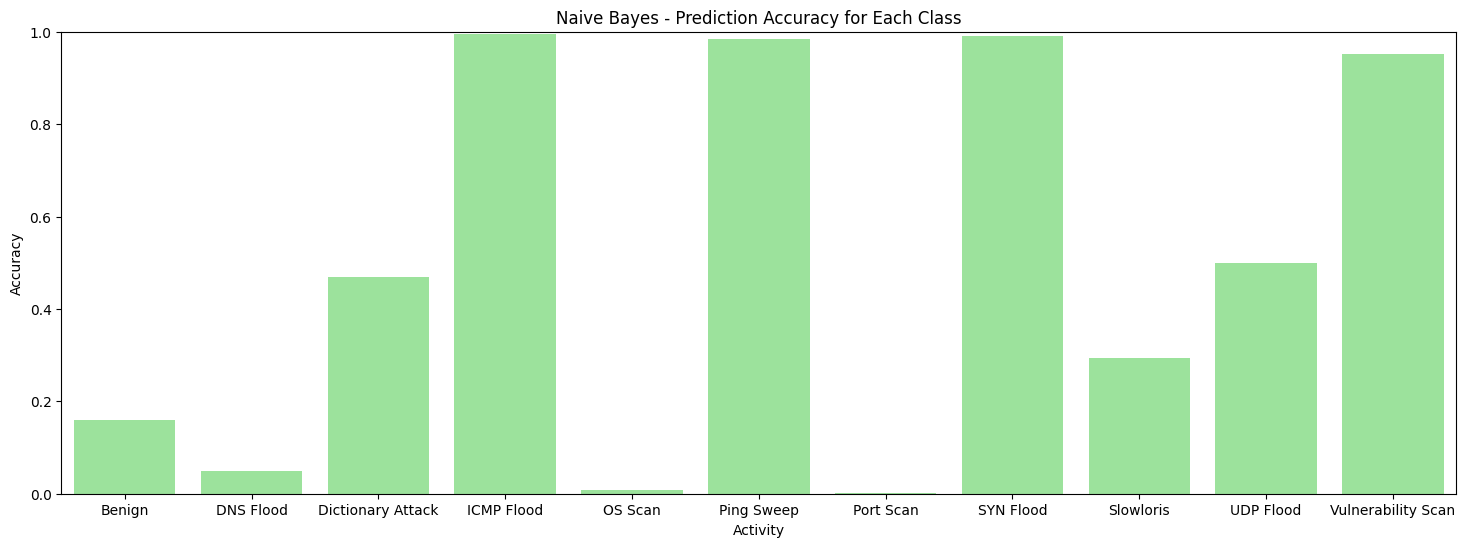

In [ ]:
class_accuracy_knn = conf_matrix.diagonal() / conf_matrix.sum(axis=1)

plt.figure(figsize=(18, 6))
sns.barplot(x=knn_model.classes_, y=class_accuracy_knn, color='lightgreen')
plt.title('Naive Bayes - Prediction Accuracy for Each Class')
plt.xlabel('Activity')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

##**Model 4: Logistic Regression**###

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


logistic_model = LogisticRegression(max_iter=200, solver='lbfgs', random_state=42)
logistic_model.fit(X_train, Y_train)
Y_pred_logistic = logistic_model.predict(X_test)

accuracy_logistic = accuracy_score(Y_test, Y_pred_logistic)
print(f'Logistic Regression Accuracy: {accuracy_logistic:.2f}')
print("Classification Report:\n")
print(classification_report(Y_test, Y_pred_logistic))

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.75
Classification Report:



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                    precision    recall  f1-score   support

            Benign       0.77      0.71      0.74      2394
         DNS Flood       0.50      0.01      0.02       343
 Dictionary Attack       0.21      0.06      0.10        47
        ICMP Flood       0.93      0.99      0.96      1646
           OS Scan       0.00      0.00      0.00       274
        Ping Sweep       0.00      0.00      0.00       526
         Port Scan       0.68      0.97      0.80      3225
         SYN Flood       0.00      0.00      0.00       101
         Slowloris       0.00      0.00      0.00       136
         UDP Flood       0.00      0.00      0.00         6
Vulnerability Scan       0.70      0.90      0.79       289

          accuracy                           0.75      8987
         macro avg       0.35      0.33      0.31      8987
      weighted avg       0.66      0.75      0.69      8987



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Visualaization

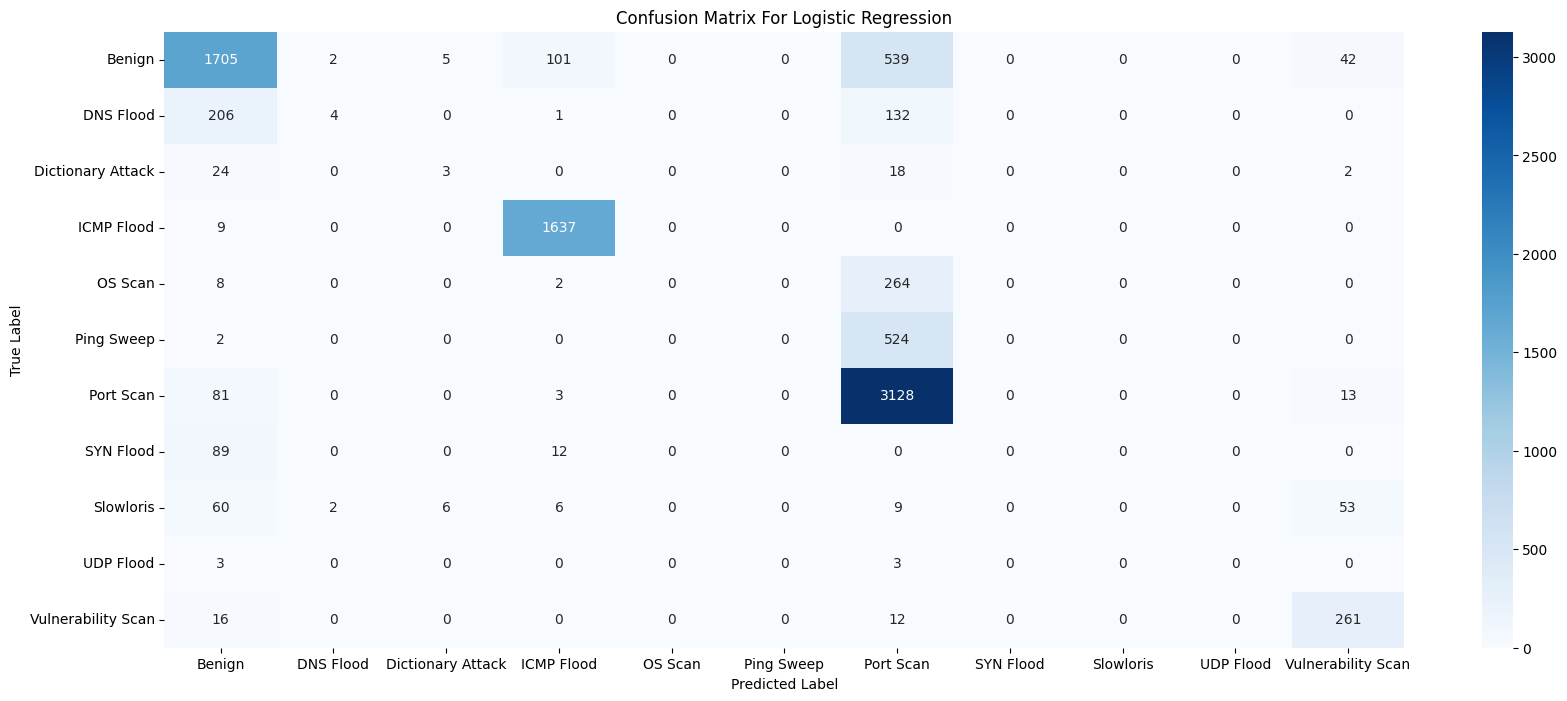

In [ ]:
from sklearn.metrics import confusion_matrix

conf_matrix_logistic = confusion_matrix(Y_test, Y_pred_logistic)

plt.figure(figsize=(20, 8))
sns.heatmap(conf_matrix_logistic, annot=True, fmt='d', cmap='Blues', xticklabels=logistic_model.classes_, yticklabels=logistic_model.classes_)
plt.title('Confusion Matrix For Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

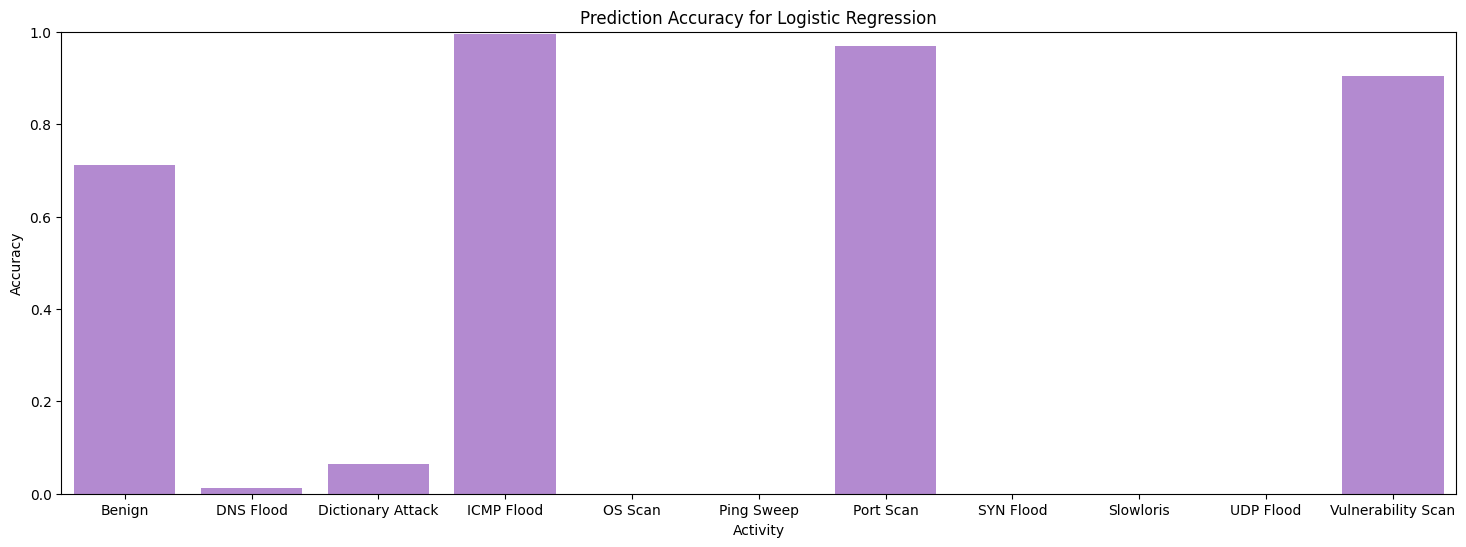

In [ ]:
class_accuracy_logistic = conf_matrix_logistic.diagonal() / conf_matrix_logistic.sum(axis=1)

plt.figure(figsize=(18, 6))
sns.barplot(x=logistic_model.classes_, y=class_accuracy_logistic, color='#B57EDC')
plt.title('Prediction Accuracy for Logistic Regression')
plt.xlabel('Activity')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()